> Context engineering is becoming a **craft** that agents builders should aim to master.
> 
> 最近也听了 shunyu yao 在小宇宙的博客：Agent & Env

- 重视基础概念与原理，要把概念搞清楚，越基础的东西越本质；
- ReAct 包括再然后的 Reflexion（引入 trial-error 的 reflection）
    - 都是对 LLM 适配（或者探索 LLM potential）的早期实践，站在现在的角度是面相 Agent（通过调用工具跟环境交互）的；
        - 如同 CoT（let's think step by step）启发了 prompt engineering 一样
    - maybe 也启发了后来 gpt api 的 function calling 能力的开发；
- 两个版本的实现
    - `from langchain.agents import create_react_agent`
    - `from langgraph.prebuilt import create_react_agent`
    - 设计的初衷
        - 把“提示词技巧”转换成“可维护的代理控制流”，并与工具调用/记忆/结构化输出等能力无缝结合。
- 如何结合 langsmith 平台 check 模型的输入输出
    - `LANGSMITH_API_KEY=xx`
    - `LANGCHAIN_TRACING_V2=true`
    - `LANGCHAIN_PROJECT=learning`

In [1]:
from IPython.display import Image

In [2]:
Image(url='https://react-lm.github.io/files/diagram.png', width=500)

In [3]:
from dotenv import load_dotenv
from ast import literal_eval
assert load_dotenv()

In [4]:
from langchain_community.tools.tavily_search import TavilySearchResults

tools = [TavilySearchResults(max_results=3)]

/tmp/ipykernel_748731/2518516040.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tools = [TavilySearchResults(max_results=3)]


### langchain

In [5]:
from langchain_openai import ChatOpenAI
from langchain import hub
from langchain.agents import AgentExecutor, create_react_agent

prompt = hub.pull("hwchase17/react")

In [6]:
# 泛化性和通用性：thought, action (env.step(action)), observation (executed feedback)
# 针对特定场景，特殊设计
print(prompt.template)

Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}


In [7]:
# Choose the LLM that will drive the agent
llm = ChatOpenAI(model="gpt-4.1-nano")
agent = create_react_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools)

In [8]:
agent_executor.invoke({'input': '"what is the hometown of the current Australia open winner?'})

{'input': '"what is the hometown of the current Australia open winner?',
 'output': "The hometown of the current Australia Open men's singles winner, Jannik Sinner, is San Candido (Innichen), Italy. The women's singles winner, Aryna Sabalenka, hails from Minsk, Belarus."}

### langgraph

- references
    - https://langchain-ai.github.io/langgraph/how-tos/react-agent-from-scratch
    - https://ai.google.dev/gemini-api/docs/langgraph-example

In [9]:
from langgraph.prebuilt import create_react_agent

In [10]:
agent = create_react_agent(
    model=llm,
    tools=tools,
)

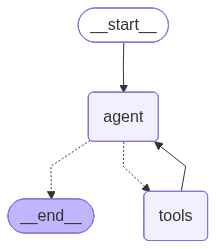

In [12]:
from IPython.display import Image, display

# 理解虚边，所谓的条件边
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [13]:
# 继续多轮的消息机制
response = agent.invoke({"messages": 
                         [{'role': 'user', 
                           'content': 'what is the hometown of the current Australia open winner?'}
                         ]}
                       )

In [15]:
for msg in response['messages']:
    print(msg.type)

human
ai
tool
tool
ai


In [14]:
from rich.pretty import pprint
pprint(response)

{
│   'messages': [
│   │   HumanMessage(
│   │   │   content='what is the hometown of the current Australia open winner?',
│   │   │   additional_kwargs={},
│   │   │   response_metadata={},
│   │   │   id='454c6d57-4247-4eda-b5db-b48f8f665b8d'
│   │   ),
│   │   AIMessage(
│   │   │   content='',
│   │   │   additional_kwargs={
│   │   │   │   'tool_calls': [
│   │   │   │   │   {
│   │   │   │   │   │   'id': 'call_eJCgDhw0r5hU7RoCgL8jBxXG',
│   │   │   │   │   │   'function': {
│   │   │   │   │   │   │   'arguments': '{"query": "Current Australian Open winner"}',
│   │   │   │   │   │   │   'name': 'tavily_search_results_json'
│   │   │   │   │   │   },
│   │   │   │   │   │   'type': 'function'
│   │   │   │   │   },
│   │   │   │   │   {
│   │   │   │   │   │   'id': 'call_JaJuiwSns4qAEQeiCG613A3N',
│   │   │   │   │   │   'function': {
│   │   │   │   │   │   │   'arguments': '{"query": "Hometown of current Australian Open winner"}',
│   │   │   │   │   │   │   'name': 'tavily_search_results_json'
│   │   │   │   │   │   },
│   │   │   │   │   │   'type': 'function'
│   │   │   │   │   }
│   │   │   │   ],
│   │   │   │   'refusal': None
│   │   │   },
│   │   │   response_metadata={
│   │   │   │   'token_usage': {
│   │   │   │   │   'completion_tokens': 61,
│   │   │   │   │   'prompt_tokens': 90,
│   │   │   │   │   'total_tokens': 151,
│   │   │   │   │   'completion_tokens_details': {
│   │   │   │   │   │   'accepted_prediction_tokens': 0,
│   │   │   │   │   │   'audio_tokens': 0,
│   │   │   │   │   │   'reasoning_tokens': 0,
│   │   │   │   │   │   'rejected_prediction_tokens': 0
│   │   │   │   │   },
│   │   │   │   │   'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
│   │   │   │   },
│   │   │   │   'model_name': 'gpt-4.1-nano-2025-04-14',
│   │   │   │   'system_fingerprint': 'fp_7c233bf9d1',
│   │   │   │   'id': 'chatcmpl-CK3VCq5TqzS0HEMNnL0TT5IOt2cW5',
│   │   │   │   'service_tier': 'default',
│   │   │   │   'finish_reason': 'tool_calls',
│   │   │   │   'logprobs': None
│   │   │   },
│   │   │   id='run--964ec730-396a-4b2c-b923-6389323510ff-0',
│   │   │   tool_calls=[
│   │   │   │   {
│   │   │   │   │   'name': 'tavily_search_results_json',
│   │   │   │   │   'args': {'query': 'Current Australian Open winner'},
│   │   │   │   │   'id': 'call_eJCgDhw0r5hU7RoCgL8jBxXG',
│   │   │   │   │   'type': 'tool_call'
│   │   │   │   },
│   │   │   │   {
│   │   │   │   │   'name': 'tavily_search_results_json',
│   │   │   │   │   'args': {'query': 'Hometown of current Australian Open winner'},
│   │   │   │   │   'id': 'call_JaJuiwSns4qAEQeiCG613A3N',
│   │   │   │   │   'type': 'tool_call'
│   │   │   │   }
│   │   │   ],
│   │   │   usage_metadata={
│   │   │   │   'input_tokens': 90,
│   │   │   │   'output_tokens': 61,
│   │   │   │   'total_tokens': 151,
│   │   │   │   'input_token_details': {'audio': 0, 'cache_read': 0},
│   │   │   │   'output_token_details': {'audio': 0, 'reasoning': 0}
│   │   │   }
│   │   ),
│   │   ToolMessage(
│   │   │   content='[{"title": "Australian Open winners: Men\'s and women\'s singles ...", "url": "https://www.espn.com/tennis/story/_/id/39343618/australian-open-winners-mens-womens-singles-champions", "content": "Overall, Novak Djokovic has won the most Australian Open titles in the Open era, with 10. Serena Williams leads the women\'s side, with seven titles. Let\'s take a look at every Australian Open winner over the years:\\n\\nMEN\'S SINGLES CHAMPIONS\\n\\n2025: Jannik Sinner\\n\\n2024: Jannik Sinner\\n\\n2023: Novak Djokovic\\n\\n2022: Rafael Nadal\\n\\n2021: Novak Djokovic\\n\\n2020: Novak Djokovic\\n\\n2019: Novak Djokovic\\n\\n2018: Roger Federer\\n\\n2017: Roger Federer\\n\\n2016: Novak Djokovic\\n\\n2015: Novak Djokovic\\n\\n2014: Stan Wawrinka [...] ## ESPN\\n\\n# Australian Open winners: Men\'s and women\'s singles champions\\n\\nCopy Link\\n\\nThe 2025 Australian Open has come to a close. Jannik Sinner beat Alexander Zverev in the me